In [83]:
import sys
import subprocess
import pandas as pd
import numpy as np
import requests
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine
import tweepy
import openai
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import xgboost as xgb
import joblib
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import streamlit as st
import nltk
from nltk.corpus import stopwords
from collections import Counter
from sklearn.decomposition import PCA

# Step 0: Connecting to SQL Database

In [2]:
# Verify Database and proper tokens exist in .env file
from dotenv import load_dotenv

load_dotenv()

print("Database URL found:", os.getenv("DATABASE_URL") is not None)
print("Twitter token found:", os.getenv("X_BEARER_TOKEN") is not None)

Database URL found: True
Twitter token found: True


In [3]:
# Connect to the database and run a simple query to verify connection
from sqlalchemy import create_engine, text

engine = create_engine(os.getenv("DATABASE_URL"))

with engine.connect() as conn:
    result = conn.execute(
        text("SELECT current_database(), current_user")
    )
    
    print(result.fetchone())

('twitter_engagement', 'postgres')


In [4]:
# Verify tables exist in the database
query = """
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'public'
ORDER BY table_name
"""

with engine.connect() as conn:
    result = conn.execute(text(query))

    for row in result:
        print(row[0])

tweet_labels
tweet_media
tweet_modeling_dataset
tweets
users


# Step 1: Getting Twitter Data

In [5]:
import os
import re
import json
import pandas as pd
import tweepy

from dotenv import load_dotenv
from sqlalchemy import create_engine, text

load_dotenv()

engine = create_engine(os.getenv("DATABASE_URL"))

client = tweepy.Client(
    bearer_token=os.getenv("X_BEARER_TOKEN"),
    wait_on_rate_limit=True
)

print("Setup complete")

Setup complete


In [6]:
# Text cleaning function
def clean_tweet_text(text):
    if text is None:
        return None
    
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "@USER", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\s+", " ", text)
    
    return text.strip()

In [10]:
# Defining time windows and test queries for data collection
from datetime import datetime, timedelta, timezone
import pandas as pd

now = datetime.now(timezone.utc)

# Each tuple is: (start_days_ago, end_days_ago)
# Example: 7.0 to 6.8 days ago means older tweets with time to gain engagement.
time_windows = [
    (7.0, 6.8),
    (6.8, 6.6),
    (6.6, 6.4),
    (6.4, 6.2),
    (6.2, 6.0)
]

test_queries = {
    "broad_general": '("the" OR "this" OR "you" OR "that" OR "with") lang:en -is:retweet',
    "questions": '("why" OR "how" OR "what" OR "when" OR "where") lang:en -is:retweet',
    "opinions": '("best" OR "worst" OR "favorite" OR "overrated" OR "underrated") lang:en -is:retweet',
    "entertainment": '("movie" OR "music" OR "game" OR "show" OR "book") lang:en -is:retweet',
    "life_topics": '("food" OR "travel" OR "work" OR "school" OR "fitness") lang:en -is:retweet'
}


In [11]:
# Test collection
all_responses = []

for query_name, query_text in test_queries.items():
    for start_days, end_days in time_windows:
        start_time = now - timedelta(days=start_days)
        end_time = now - timedelta(days=end_days)

        start_time_str = start_time.isoformat(timespec="seconds").replace("+00:00", "Z")
        end_time_str = end_time.isoformat(timespec="seconds").replace("+00:00", "Z")

        response = client.search_recent_tweets(
            query=query_text,
            max_results=10,
            start_time=start_time_str,
            end_time=end_time_str,
            sort_order="relevancy",
            tweet_fields=[
                "created_at",
                "author_id",
                "lang",
                "public_metrics",
                "entities",
                "attachments",
                "referenced_tweets"
            ],
            expansions=[
                "attachments.media_keys",
                "author_id",
                "referenced_tweets.id"
            ],
            media_fields=[
                "media_key",
                "type",
                "url",
                "preview_image_url",
                "alt_text",
                "width",
                "height",
                "duration_ms",
                "public_metrics"
            ],
            user_fields=[
                "username",
                "name",
                "verified",
                "public_metrics"
            ]
        )

        tweet_count = 0 if response.data is None else len(response.data)

        print(
            f"{query_name} | {start_time_str} to {end_time_str} | tweets returned: {tweet_count}"
        )

        all_responses.append({
            "query_name": query_name,
            "query_text": query_text,
            "start_time": start_time_str,
            "end_time": end_time_str,
            "response": response,
            "tweet_count": tweet_count
        })

print("Total API calls made:", len(all_responses))
print("Total tweets returned before deduping:", sum(r["tweet_count"] for r in all_responses))

broad_general | 2026-06-04T18:59:35Z to 2026-06-04T23:47:35Z | tweets returned: 10
broad_general | 2026-06-04T23:47:35Z to 2026-06-05T04:35:35Z | tweets returned: 10
broad_general | 2026-06-05T04:35:35Z to 2026-06-05T09:23:35Z | tweets returned: 10
broad_general | 2026-06-05T09:23:35Z to 2026-06-05T14:11:35Z | tweets returned: 10
broad_general | 2026-06-05T14:11:35Z to 2026-06-05T18:59:35Z | tweets returned: 10
questions | 2026-06-04T18:59:35Z to 2026-06-04T23:47:35Z | tweets returned: 10
questions | 2026-06-04T23:47:35Z to 2026-06-05T04:35:35Z | tweets returned: 9
questions | 2026-06-05T04:35:35Z to 2026-06-05T09:23:35Z | tweets returned: 10
questions | 2026-06-05T09:23:35Z to 2026-06-05T14:11:35Z | tweets returned: 10
questions | 2026-06-05T14:11:35Z to 2026-06-05T18:59:35Z | tweets returned: 10
opinions | 2026-06-04T18:59:35Z to 2026-06-04T23:47:35Z | tweets returned: 10
opinions | 2026-06-04T23:47:35Z to 2026-06-05T04:35:35Z | tweets returned: 9
opinions | 2026-06-05T04:35:35Z to 2

In [12]:
# Vareity check

test_rows = []

for item in all_responses:
    response = item["response"]

    for tweet in response.data or []:
        metrics = tweet.public_metrics or {}

        test_rows.append({
            "tweet_id": str(tweet.id),
            "query_name": item["query_name"],
            "start_time_window": item["start_time"],
            "end_time_window": item["end_time"],
            "created_at": tweet.created_at,
            "text": tweet.text,
            "like_count": metrics.get("like_count", 0),
            "reply_count": metrics.get("reply_count", 0),
            "retweet_count": metrics.get("retweet_count", 0),
            "quote_count": metrics.get("quote_count", 0),
        })

test_df = pd.DataFrame(test_rows)

test_df["engagement_total"] = (
    test_df["like_count"] +
    test_df["reply_count"] +
    test_df["retweet_count"] +
    test_df["quote_count"]
)

test_df = test_df.drop_duplicates(subset="tweet_id")

print("Unique tweets:", len(test_df))
print("Unique queries represented:", test_df["query_name"].nunique())
print("Created_at range:", test_df["created_at"].min(), "to", test_df["created_at"].max())

display(
    test_df[[
        "query_name",
        "created_at",
        "like_count",
        "reply_count",
        "retweet_count",
        "quote_count",
        "engagement_total",
        "text"
    ]]
    .sort_values("engagement_total", ascending=False)
    .head(25)
)

Unique tweets: 243
Unique queries represented: 5
Created_at range: 2026-06-04 19:00:30+00:00 to 2026-06-05 18:44:39+00:00


,query_name,created_at,like_count,reply_count,retweet_count,quote_count,engagement_total,text
169,entertainment,2026-06-05 08:18:54+00:00,2798,40,367,16,3221,In the Game Boy Color educational game Blue's ...
198,life_topics,2026-06-04 19:17:15+00:00,599,221,47,249,1116,What fast food spot did you work at? I worked ...
192,entertainment,2026-06-05 18:32:07+00:00,647,7,10,0,664,My favorite Bond book is Moonraker for this ve...
203,life_topics,2026-06-04 21:25:26+00:00,326,37,99,6,468,Connecticut is spending millions of your tax m...
34,broad_general,2026-06-05 12:55:49+00:00,308,4,129,12,453,𝙐𝙉𝘿𝙀𝙍 𝙏𝙃𝙀 𝙈𝙊𝙊𝙉 𝘼𝙉𝘿 𝙎𝙏𝘼𝙍𝙎 🌙✨\n\n𝙎𝙤𝙢𝙚 𝙣𝙞𝙜𝙝𝙩𝙨 𝙚𝙣𝙙...
28,broad_general,2026-06-05 04:35:36+00:00,343,39,19,1,402,In bear markets you absolutely just do not buy...
208,life_topics,2026-06-05 03:32:16+00:00,297,25,10,0,332,The worst form of fitness is when you start th...
145,opinions,2026-06-05 14:14:32+00:00,222,28,13,20,283,Who’s the most overrated / underrated Monarch ...
48,broad_general,2026-06-05 14:44:05+00:00,235,30,5,1,271,@PhiloGroves Let me explain why this happens. ...
78,questions,2026-06-05 08:00:01+00:00,126,139,2,1,268,i think people often confuse performance with ...


In [13]:
# DataFrame creation from multiple query/time-window responses

tweet_rows = []
media_rows = []
user_rows = []

for item in all_responses:
    response = item["response"]
    query_name = item["query_name"]
    query_text = item["query_text"]
    start_time_window = item["start_time"]
    end_time_window = item["end_time"]

    tweets = response.data or []
    includes = response.includes or {}

    media_lookup = {
        media.data["media_key"]: media
        for media in includes.get("media", [])
    }

    # users
    for user in includes.get("users", []):
        metrics = user.data.get("public_metrics", {})

        user_rows.append({
            "author_id": str(user.id),
            "username": user.data.get("username"),
            "name": user.data.get("name"),
            "verified": user.data.get("verified"),
            "followers_count": metrics.get("followers_count", 0),
            "following_count": metrics.get("following_count", 0),
            "tweet_count": metrics.get("tweet_count", 0),
            "listed_count": metrics.get("listed_count", 0),
            "raw_json": json.dumps(user.data)
        })

    # tweets and media
    for tweet in tweets:
        metrics = tweet.public_metrics or {}
        attachments = tweet.data.get("attachments", {})
        media_keys = attachments.get("media_keys", [])

        tweet_rows.append({
            "tweet_id": str(tweet.id),
            "author_id": str(tweet.author_id),
            "created_at": tweet.created_at,
            "text": tweet.text,
            "clean_text": clean_tweet_text(tweet.text),
            "lang": tweet.lang,

            "retweet_count": metrics.get("retweet_count", 0),
            "reply_count": metrics.get("reply_count", 0),
            "like_count": metrics.get("like_count", 0),
            "quote_count": metrics.get("quote_count", 0),

            "has_media": len(media_keys) > 0,
            "media_count": len(media_keys),

            "collection_source": query_name,
            "search_query": query_text,

            # useful for testing; not currently in your database unless you add columns
            "start_time_window": start_time_window,
            "end_time_window": end_time_window,

            "raw_json": json.dumps(tweet.data)
        })

        for media_key in media_keys:
            media = media_lookup.get(media_key)

            if media is None:
                continue

            media_rows.append({
                "media_key": media_key,
                "tweet_id": str(tweet.id),
                "media_type": media.data.get("type"),
                "url": media.data.get("url"),
                "preview_image_url": media.data.get("preview_image_url"),
                "alt_text": media.data.get("alt_text"),
                "width": media.data.get("width"),
                "height": media.data.get("height"),
                "duration_ms": media.data.get("duration_ms"),
                "public_metrics": json.dumps(media.data.get("public_metrics", {})),
                "raw_json": json.dumps(media.data)
            })

tweets_df = pd.DataFrame(tweet_rows)
media_df = pd.DataFrame(media_rows)
users_df = pd.DataFrame(user_rows)

# Deduplicate
if len(tweets_df) > 0:
    tweets_df = tweets_df.drop_duplicates(subset="tweet_id").copy()

if len(media_df) > 0:
    media_df = media_df.drop_duplicates(subset="media_key").copy()

if len(users_df) > 0:
    users_df = users_df.drop_duplicates(subset="author_id").copy()

# Engagement features
if len(tweets_df) > 0:
    tweets_df["engagement_total"] = (
        tweets_df["like_count"] +
        tweets_df["reply_count"] +
        tweets_df["retweet_count"] +
        tweets_df["quote_count"]
    )

    tweets_df = tweets_df.sort_values(by="engagement_total", ascending=False)



tweets_df["eligible_for_labeling"] = (
    tweets_df["engagement_total"] >= 2
)

# Propagate eligible_for_labeling to media_df and users_df
tweet_eligibility_lookup = (
    tweets_df
    .set_index("tweet_id")["eligible_for_labeling"]
    .to_dict()
)

user_eligibility_lookup = (
    tweets_df
    .groupby("author_id")["eligible_for_labeling"]
    .any()
    .to_dict()
)

if len(media_df) > 0:
    media_df["eligible_for_labeling"] = (
        media_df["tweet_id"]
        .map(tweet_eligibility_lookup)
        .fillna(False)
    )
else:
    media_df["eligible_for_labeling"] = pd.Series(dtype=bool)

if len(users_df) > 0:
    users_df["eligible_for_labeling"] = (
        users_df["author_id"]
        .map(user_eligibility_lookup)
        .fillna(False)
    )
else:
    users_df["eligible_for_labeling"] = pd.Series(dtype=bool)

display(tweets_df.head())
display(media_df.head())
display(users_df.head())

,tweet_id,author_id,created_at,text,clean_text,lang,retweet_count,reply_count,like_count,quote_count,has_media,media_count,collection_source,search_query,start_time_window,end_time_window,raw_json,engagement_total,eligible_for_labeling
169,2062811385613156799,1805986061467951104,2026-06-05 08:18:54+00:00,In the Game Boy Color educational game Blue's ...,In the Game Boy Color educational game Blue's ...,en,367,40,2798,16,True,1,entertainment,"(""movie"" OR ""music"" OR ""game"" OR ""show"" OR ""bo...",2026-06-05T04:35:35Z,2026-06-05T09:23:35Z,"{""entities"": {""urls"": [{""start"": 222, ""end"": 2...",3221,True
198,2062614676660187382,94844786,2026-06-04 19:17:15+00:00,What fast food spot did you work at? I worked ...,What fast food spot did you work at? I worked ...,en,47,221,599,249,False,0,life_topics,"(""food"" OR ""travel"" OR ""work"" OR ""school"" OR ""...",2026-06-04T18:59:35Z,2026-06-04T23:47:35Z,"{""author_id"": ""94844786"", ""edit_history_tweet_...",1116,True
192,2062965706996723879,1668704081102389249,2026-06-05 18:32:07+00:00,My favorite Bond book is Moonraker for this ve...,My favorite Bond book is Moonraker for this ve...,en,10,7,647,0,False,0,entertainment,"(""movie"" OR ""music"" OR ""game"" OR ""show"" OR ""bo...",2026-06-05T14:11:35Z,2026-06-05T18:59:35Z,"{""author_id"": ""1668704081102389249"", ""edit_his...",664,True
203,2062646937158140250,62812958,2026-06-04 21:25:26+00:00,Connecticut is spending millions of your tax m...,Connecticut is spending millions of your tax m...,en,99,37,326,6,False,0,life_topics,"(""food"" OR ""travel"" OR ""work"" OR ""school"" OR ""...",2026-06-04T18:59:35Z,2026-06-04T23:47:35Z,"{""author_id"": ""62812958"", ""edit_history_tweet_...",468,True
34,2062881075488338317,1979572602617331712,2026-06-05 12:55:49+00:00,𝙐𝙉𝘿𝙀𝙍 𝙏𝙃𝙀 𝙈𝙊𝙊𝙉 𝘼𝙉𝘿 𝙎𝙏𝘼𝙍𝙎 🌙✨\n\n𝙎𝙤𝙢𝙚 𝙣𝙞𝙜𝙝𝙩𝙨 𝙚𝙣𝙙...,"𝙐𝙉𝘿𝙀𝙍 𝙏𝙃𝙀 𝙈𝙊𝙊𝙉 𝘼𝙉𝘿 𝙎𝙏𝘼𝙍𝙎 🌙✨ 𝙎𝙤𝙢𝙚 𝙣𝙞𝙜𝙝𝙩𝙨 𝙚𝙣𝙙, 𝙗...",en,129,4,308,12,True,1,broad_general,"(""the"" OR ""this"" OR ""you"" OR ""that"" OR ""with"")...",2026-06-05T09:23:35Z,2026-06-05T14:11:35Z,"{""text"": ""\ud835\ude50\ud835\ude49\ud835\ude3f...",453,True


,media_key,tweet_id,media_type,url,preview_image_url,alt_text,width,height,duration_ms,public_metrics,raw_json,eligible_for_labeling
0,3_2062636441377648640,2062636444473024953,photo,https://pbs.twimg.com/media/HJ_06kUXMAAxyFk.jpg,NaN,NaN,500,587,NaN,{},"{""media_key"": ""3_2062636441377648640"", ""type"":...",True
1,13_2062641289586147328,2062641777677353293,video,NaN,https://pbs.twimg.com/amplify_video_thumb/2062...,NaN,1080,1920,244266.0,"{""view_count"": 3248}","{""media_key"": ""13_2062641289586147328"", ""durat...",True
2,3_2062638641743347712,2062638653260861656,photo,https://pbs.twimg.com/media/HJ_26pUbQAASie6.jpg,NaN,NaN,1983,793,NaN,{},"{""media_key"": ""3_2062638641743347712"", ""type"":...",True
3,16_2062746391919898624,2062746399603638661,animated_gif,NaN,https://pbs.twimg.com/tweet_video_thumb/HKBY6i...,NaN,320,480,NaN,{},"{""media_key"": ""16_2062746391919898624"", ""width...",True
4,3_2062701456998682624,2062701464888471953,photo,https://pbs.twimg.com/media/HKAwC-YWUAATsTN.jpg,NaN,NaN,1728,1152,NaN,{},"{""media_key"": ""3_2062701456998682624"", ""width""...",True


,author_id,username,name,verified,followers_count,following_count,tweet_count,listed_count,raw_json,eligible_for_labeling
0,1214757469785747457,ripchillpill,Chill Pill 🔮 (Bald),False,97455,8973,329515,1849,"{""username"": ""ripchillpill"", ""name"": ""Chill Pi...",True
1,1503515073293303811,OT5DTour,OT5 Daily Tour,False,6085,10,28061,45,"{""username"": ""OT5DTour"", ""name"": ""OT5 Daily To...",True
2,1748811596711739393,M_O_Gwhy,𓊈 Mₐₗₐcₕᵢ Mᵤₛₜ Dᵢₑ♱𓊉,False,643,440,16129,9,"{""username"": ""M_O_Gwhy"", ""name"": ""\ud80c\ude88...",False
3,1778705111730049024,MatthewBac60261,Matt Do unto others.....,False,6064,7502,113769,7,"{""username"": ""MatthewBac60261"", ""name"": ""Matt ...",True
4,1351882364838944768,Damon22l,Damon,False,27593,443,334328,94,"{""username"": ""Damon22l"", ""name"": ""Damon"", ""id""...",True


engagement_total    39.699588
dtype: float64
243
count     243.000000
mean       39.699588
std       229.947057
min         0.000000
25%         0.000000
50%         1.000000
75%         5.500000
max      3221.000000
Name: engagement_total, dtype: float64


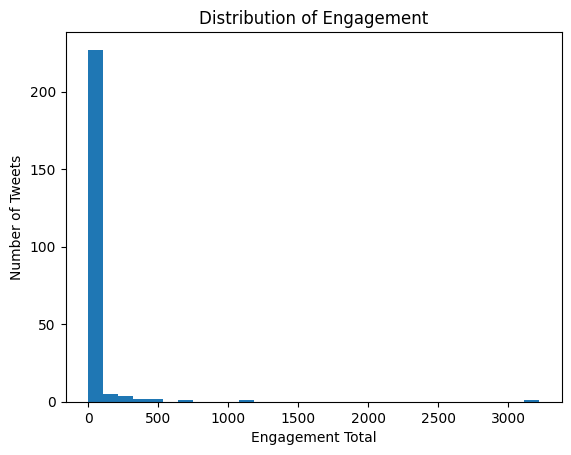

In [14]:

print(tweets_df[['engagement_total']].mean())
print(len(tweets_df))
print(tweets_df["engagement_total"].describe())

import matplotlib.pyplot as plt

plt.hist(tweets_df["engagement_total"], bins=30)
plt.xlabel("Engagement Total")
plt.ylabel("Number of Tweets")
plt.title("Distribution of Engagement")
plt.show()

In [15]:
print("Tweets:", len(tweets_df))
print("Media:", len(media_df))
print("Users:", len(users_df))

print("Duplicate tweets:", tweets_df["tweet_id"].duplicated().sum())
print("Duplicate media:", media_df["media_key"].duplicated().sum() if len(media_df) > 0 else 0)
print("Duplicate users:", users_df["author_id"].duplicated().sum() if len(users_df) > 0 else 0)

print(tweets_df["engagement_total"].describe())

Tweets: 243
Media: 94
Users: 231
Duplicate tweets: 0
Duplicate media: 0
Duplicate users: 0
count     243.000000
mean       39.699588
std       229.947057
min         0.000000
25%         0.000000
50%         1.000000
75%         5.500000
max      3221.000000
Name: engagement_total, dtype: float64


In [16]:
# Verifying correct data structure before SQL insertion
print("tweets_df:", tweets_df.shape)
print("media_df:", media_df.shape)
print("users_df:", users_df.shape)

print("Tweet columns:")
print(tweets_df.columns.tolist())

print("Media columns:")
print(media_df.columns.tolist())

print("User columns:")
print(users_df.columns.tolist())

tweets_df: (243, 19)
media_df: (94, 12)
users_df: (231, 10)
Tweet columns:
['tweet_id', 'author_id', 'created_at', 'text', 'clean_text', 'lang', 'retweet_count', 'reply_count', 'like_count', 'quote_count', 'has_media', 'media_count', 'collection_source', 'search_query', 'start_time_window', 'end_time_window', 'raw_json', 'engagement_total', 'eligible_for_labeling']
Media columns:
['media_key', 'tweet_id', 'media_type', 'url', 'preview_image_url', 'alt_text', 'width', 'height', 'duration_ms', 'public_metrics', 'raw_json', 'eligible_for_labeling']
User columns:
['author_id', 'username', 'name', 'verified', 'followers_count', 'following_count', 'tweet_count', 'listed_count', 'raw_json', 'eligible_for_labeling']


In [42]:
import numpy as np
import pandas as pd
import math

# Create SQL-ready copies
tweets_sql_df = tweets_df.drop(
    columns=["start_time_window", "end_time_window", "engagement_total"],
    errors="ignore"
).copy()

media_sql_df = media_df.copy()
users_sql_df = users_df.copy()

# Replace NaN / NA / NaT with None across all DataFrames
tweets_sql_df = tweets_sql_df.where(pd.notnull(tweets_sql_df), None)
media_sql_df = media_sql_df.where(pd.notnull(media_sql_df), None)
users_sql_df = users_sql_df.where(pd.notnull(users_sql_df), None)

# Convert media numeric fields to SQL-friendly integers or None
for col in ["width", "height", "duration_ms"]:
    if col in media_sql_df.columns:
        media_sql_df[col] = media_sql_df[col].apply(
            lambda x: None if x is None or pd.isna(x) else int(x)
        )
        media_sql_df[col] = media_sql_df[col].astype(object)
        media_sql_df[col] = media_sql_df[col].where(pd.notnull(media_sql_df[col]), None)

# Convert user numeric fields to SQL-friendly integers or None
for col in [
    "followers_count",
    "following_count",
    "tweet_count",
    "listed_count",
    "user_like_count",
    "user_media_count"
]:
    if col in users_sql_df.columns:
        users_sql_df[col] = users_sql_df[col].apply(
            lambda x: None if x is None or pd.isna(x) else int(x)
        )
        users_sql_df[col] = users_sql_df[col].astype(object)
        users_sql_df[col] = users_sql_df[col].where(pd.notnull(users_sql_df[col]), None)

# Final hard cleanup before SQL insert
tweets_records = tweets_sql_df.to_dict(orient="records")
media_records = media_sql_df.to_dict(orient="records")
users_records = users_sql_df.to_dict(orient="records")

def clean_record(record):
    return {
        key: (None if isinstance(value, float) and math.isnan(value) else value)
        for key, value in record.items()
    }

tweets_records = [clean_record(r) for r in tweets_records]
media_records = [clean_record(r) for r in media_records]
users_records = [clean_record(r) for r in users_records]

In [39]:
# Defining SQL Insertion functions
from sqlalchemy import text

insert_users_sql = text("""
INSERT INTO users (
    author_id, username, name, verified,
    followers_count, following_count, tweet_count, listed_count,
    eligible_for_labeling,
    raw_json
)
VALUES (
    :author_id, :username, :name, :verified,
    :followers_count, :following_count, :tweet_count, :listed_count,
    :eligible_for_labeling,
    CAST(:raw_json AS JSONB)
)
ON CONFLICT (author_id) DO UPDATE SET
    username = EXCLUDED.username,
    name = EXCLUDED.name,
    verified = EXCLUDED.verified,
    followers_count = EXCLUDED.followers_count,
    following_count = EXCLUDED.following_count,
    tweet_count = EXCLUDED.tweet_count,
    listed_count = EXCLUDED.listed_count,
    eligible_for_labeling = EXCLUDED.eligible_for_labeling,
    raw_json = EXCLUDED.raw_json;
""")

insert_tweets_sql = text("""
INSERT INTO tweets (
    tweet_id, author_id, created_at, text, clean_text, lang,
    retweet_count, reply_count, like_count, quote_count,
    has_media, media_count,
    collection_source, search_query,
    eligible_for_labeling,
    raw_json
)
VALUES (
    :tweet_id, :author_id, :created_at, :text, :clean_text, :lang,
    :retweet_count, :reply_count, :like_count, :quote_count,
    :has_media, :media_count,
    :collection_source, :search_query,
    :eligible_for_labeling,
    CAST(:raw_json AS JSONB)
)
ON CONFLICT (tweet_id) DO UPDATE SET
    retweet_count = EXCLUDED.retweet_count,
    reply_count = EXCLUDED.reply_count,
    like_count = EXCLUDED.like_count,
    quote_count = EXCLUDED.quote_count,
    has_media = EXCLUDED.has_media,
    media_count = EXCLUDED.media_count,
    collection_source = EXCLUDED.collection_source,
    search_query = EXCLUDED.search_query,
    eligible_for_labeling = EXCLUDED.eligible_for_labeling,
    raw_json = EXCLUDED.raw_json;
""")

insert_media_sql = text("""
INSERT INTO tweet_media (
    media_key, tweet_id, media_type, url, preview_image_url,
    alt_text, width, height, duration_ms,
    public_metrics,
    eligible_for_labeling,
    raw_json
)
VALUES (
    :media_key, :tweet_id, :media_type, :url, :preview_image_url,
    :alt_text, :width, :height, :duration_ms,
    CAST(:public_metrics AS JSONB),
    :eligible_for_labeling,
    CAST(:raw_json AS JSONB)
)
ON CONFLICT (media_key) DO UPDATE SET
    media_type = EXCLUDED.media_type,
    url = EXCLUDED.url,
    preview_image_url = EXCLUDED.preview_image_url,
    alt_text = EXCLUDED.alt_text,
    width = EXCLUDED.width,
    height = EXCLUDED.height,
    duration_ms = EXCLUDED.duration_ms,
    public_metrics = EXCLUDED.public_metrics,
    eligible_for_labeling = EXCLUDED.eligible_for_labeling,
    raw_json = EXCLUDED.raw_json;
""")

In [43]:
# SQL Insertion
with engine.begin() as conn:
    if len(users_records) > 0:
        conn.execute(insert_users_sql, users_records)

    if len(tweets_records) > 0:
        conn.execute(insert_tweets_sql, tweets_records)

    if len(media_records) > 0:
        conn.execute(insert_media_sql, media_records)

print("Inserted/updated users:", len(users_records))
print("Inserted/updated tweets:", len(tweets_records))
print("Inserted/updated media:", len(media_records))

Inserted/updated users: 231
Inserted/updated tweets: 243
Inserted/updated media: 94


In [44]:
with engine.connect() as conn:
    print("Tweets:", conn.execute(text("SELECT COUNT(*) FROM tweets;")).scalar())
    print("Media:", conn.execute(text("SELECT COUNT(*) FROM tweet_media;")).scalar())
    print("Users:", conn.execute(text("SELECT COUNT(*) FROM users;")).scalar())
    print("Eligible tweets:", conn.execute(text("SELECT COUNT(*) FROM tweets WHERE eligible_for_labeling = TRUE;")).scalar())

Tweets: 243
Media: 94
Users: 231
Eligible tweets: 121


# Step 2: Full Automated Data Colleciton

In [45]:
# New timeframes and queries
time_windows = [
    (7.0, 6.0),
    (6.0, 5.0),
    (5.0, 4.0),
    (4.0, 3.0),
    (3.0, 2.0)
]

queries = [
    # Broad baseline
    {"name": "broad_general_1", "text": '("the" OR "this" OR "that" OR "with") lang:en -is:retweet'},
    {"name": "broad_general_2", "text": '("good" OR "people" OR "today" OR "day") lang:en -is:retweet'},
    {"name": "broad_general_3", "text": '("look" OR "think" OR "know" OR "feel") lang:en -is:retweet'},

    # Engagement-style candidates
    {"name": "engagement_reply", "text": '("reply below" OR "comment below" OR "drop your" OR "tell me") lang:en -is:retweet'},
    {"name": "engagement_share", "text": '("like this" OR "share this" OR "retweet this" OR "follow me") lang:en -is:retweet'},
    {"name": "engagement_tag", "text": '("tag someone" OR "tag a friend" OR "send this to" OR "who needs this") lang:en -is:retweet'},
    {"name": "engagement_grok", "text": '("@grok" OR "Grok explain" OR "ask Grok") lang:en -is:retweet'},
    {"name": "engagement_identity", "text": '("Full Name:" OR "Real Name:" OR "Age:" OR "Location:") lang:en -is:retweet'},

    # Clickbait / urgency
    {"name": "clickbait_news", "text": '("NEW:" OR "BREAKING:" OR "DEVELOPING:" OR "JUST IN:") lang:en -is:retweet'},
    {"name": "clickbait_emotional", "text": '("INSANE" OR "SHOCKING" OR "EXPOSED" OR "WOW") lang:en -is:retweet'},
    {"name": "emoji_urgency", "text": '("🚨" OR "🔥" OR "‼️" OR "💀") lang:en -is:retweet'},

    # Topic variety
    {"name": "sports_general", "text": '(score OR win OR lose OR stats OR game) lang:en -is:retweet'},
    {"name": "technology_general", "text": '(AI OR tech OR software OR iPhone OR Android OR data OR code OR app) lang:en -is:retweet'},
    {"name": "entertainment_general", "text": '("movie" OR "music" OR "game" OR "show" OR "book" OR "film") lang:en -is:retweet'},

    # Political/current events, useful for rage-bait/clickbait detection
    {"name": "political_general_1", "text": '("Trump" OR "Biden" OR "Republican" OR "Democrat") lang:en -is:retweet'},
    {"name": "political_general_2", "text": '("election" OR "policy" OR "Left" OR "Right" OR "Liberal" OR "Conservative") lang:en -is:retweet'},
]

In [46]:
full_responses = []

now = datetime.now(timezone.utc)

for query in queries:
    query_name = query["name"]
    query_text = query["text"]

    for start_days, end_days in time_windows:
        start_time = now - timedelta(days=start_days)
        end_time = now - timedelta(days=end_days)

        start_time_str = start_time.isoformat(timespec="seconds").replace("+00:00", "Z")
        end_time_str = end_time.isoformat(timespec="seconds").replace("+00:00", "Z")

        response = client.search_recent_tweets(
            query=query_text,
            max_results=100,
            start_time=start_time_str,
            end_time=end_time_str,
            sort_order="relevancy",
            tweet_fields=[
                "created_at", "author_id", "lang", "public_metrics",
                "entities", "attachments", "referenced_tweets"
            ],
            expansions=[
                "attachments.media_keys",
                "author_id"
            ],
            media_fields=[
                "media_key", "type", "url", "preview_image_url",
                "alt_text", "width", "height", "duration_ms", "public_metrics"
            ],
            user_fields=[
                "username", "name", "verified", "public_metrics"
            ]
        )

        tweet_count = 0 if response.data is None else len(response.data)

        print(f"{query_name} | {start_time_str} to {end_time_str} | tweets returned: {tweet_count}")

        full_responses.append({
            "query_name": query_name,
            "query_text": query_text,
            "start_time": start_time_str,
            "end_time": end_time_str,
            "response": response,
            "tweet_count": tweet_count
        })

print("Total API calls made:", len(full_responses))
print("Total tweets returned before deduping:", sum(r["tweet_count"] for r in full_responses))

broad_general_1 | 2026-06-05T19:40:42Z to 2026-06-06T19:40:42Z | tweets returned: 97
broad_general_1 | 2026-06-06T19:40:42Z to 2026-06-07T19:40:42Z | tweets returned: 93
broad_general_1 | 2026-06-07T19:40:42Z to 2026-06-08T19:40:42Z | tweets returned: 94
broad_general_1 | 2026-06-08T19:40:42Z to 2026-06-09T19:40:42Z | tweets returned: 99
broad_general_1 | 2026-06-09T19:40:42Z to 2026-06-10T19:40:42Z | tweets returned: 96
broad_general_2 | 2026-06-05T19:40:42Z to 2026-06-06T19:40:42Z | tweets returned: 96
broad_general_2 | 2026-06-06T19:40:42Z to 2026-06-07T19:40:42Z | tweets returned: 91
broad_general_2 | 2026-06-07T19:40:42Z to 2026-06-08T19:40:42Z | tweets returned: 100
broad_general_2 | 2026-06-08T19:40:42Z to 2026-06-09T19:40:42Z | tweets returned: 99
broad_general_2 | 2026-06-09T19:40:42Z to 2026-06-10T19:40:42Z | tweets returned: 98
broad_general_3 | 2026-06-05T19:40:42Z to 2026-06-06T19:40:42Z | tweets returned: 91
broad_general_3 | 2026-06-06T19:40:42Z to 2026-06-07T19:40:42Z |

In [47]:
# Full collection variety check

full_rows = []

for item in full_responses:
    response = item["response"]

    for tweet in response.data or []:
        metrics = tweet.public_metrics or {}

        full_rows.append({
            "tweet_id": str(tweet.id),
            "query_name": item["query_name"],
            "start_time_window": item["start_time"],
            "end_time_window": item["end_time"],
            "created_at": tweet.created_at,
            "text": tweet.text,
            "like_count": metrics.get("like_count", 0),
            "reply_count": metrics.get("reply_count", 0),
            "retweet_count": metrics.get("retweet_count", 0),
            "quote_count": metrics.get("quote_count", 0),
        })

full_df = pd.DataFrame(full_rows)

full_df["engagement_total"] = (
    full_df["like_count"] +
    full_df["reply_count"] +
    full_df["retweet_count"] +
    full_df["quote_count"]
)

full_df = full_df.drop_duplicates(subset="tweet_id")

print("Unique tweets:", len(full_df))
print("Unique queries represented:", full_df["query_name"].nunique())
print("Created_at range:", full_df["created_at"].min(), "to", full_df["created_at"].max())

display(
    full_df[[
        "query_name",
        "created_at",
        "like_count",
        "reply_count",
        "retweet_count",
        "quote_count",
        "engagement_total",
        "text"
    ]]
    .sort_values("engagement_total", ascending=False)
    .head(25)
)

Unique tweets: 7587
Unique queries represented: 16
Created_at range: 2026-06-05 19:41:58+00:00 to 2026-06-10 19:38:47+00:00


,query_name,created_at,like_count,reply_count,retweet_count,quote_count,engagement_total,text
295,broad_general_1,2026-06-09 01:12:33+00:00,19924,2068,968,85,23045,14 year old arrested for assaulting a teacher ...
1579,engagement_reply,2026-06-06 20:54:55+00:00,9217,118,1702,2,11039,Black fishnets + maximum exposure 🔥\nTell me y...
7258,political_general_2,2026-06-07 17:14:53+00:00,8315,204,848,36,9403,Karen Bass rigged the election in Los Angeles ...
1409,broad_general_3,2026-06-10 19:24:45+00:00,7155,396,467,39,8057,I know a setup like this for many people would...
431,broad_general_1,2026-06-09 23:02:46+00:00,5906,143,858,24,6931,"@zarahussain999 .@zarahussain999, the far righ..."
1709,engagement_reply,2026-06-08 10:33:12+00:00,4668,317,857,34,5876,"That receipt was from 2020, right? That was wh..."
4401,clickbait_emotional,2026-06-06 22:49:58+00:00,4603,21,136,14,4774,no but fr getting exposed for fucking your cou...
2213,engagement_share,2026-06-09 15:23:41+00:00,1336,101,2362,28,3827,Skenes Night: He’s due. So here’s the deal. If...
3953,clickbait_news,2026-06-07 20:55:03+00:00,2801,217,692,29,3739,"🚨JUST IN: U.S. Military on ""HIGH ALERT""\n\nPre..."
1010,broad_general_3,2026-06-06 12:17:39+00:00,2601,6,771,110,3488,💬 what do you think about people being judgy\n...


In [48]:
# Full DataFrame creation from multiple query/time-window responses

full_tweet_rows = []
full_media_rows = []
full_user_rows = []

for item in full_responses:
    response = item["response"]
    query_name = item["query_name"]
    query_text = item["query_text"]
    start_time_window = item["start_time"]
    end_time_window = item["end_time"]

    tweets = response.data or []
    includes = response.includes or {}

    media_lookup = {
        media.data["media_key"]: media
        for media in includes.get("media", [])
    }

    # users
    for user in includes.get("users", []):
        metrics = user.data.get("public_metrics", {})

        full_user_rows.append({
            "author_id": str(user.id),
            "username": user.data.get("username"),
            "name": user.data.get("name"),
            "verified": user.data.get("verified"),
            "followers_count": metrics.get("followers_count", 0),
            "following_count": metrics.get("following_count", 0),
            "tweet_count": metrics.get("tweet_count", 0),
            "listed_count": metrics.get("listed_count", 0),
            "raw_json": json.dumps(user.data)
        })

    # tweets and media
    for tweet in tweets:
        metrics = tweet.public_metrics or {}
        attachments = tweet.data.get("attachments", {})
        media_keys = attachments.get("media_keys", [])

        full_tweet_rows.append({
            "tweet_id": str(tweet.id),
            "author_id": str(tweet.author_id),
            "created_at": tweet.created_at,
            "text": tweet.text,
            "clean_text": clean_tweet_text(tweet.text),
            "lang": tweet.lang,

            "retweet_count": metrics.get("retweet_count", 0),
            "reply_count": metrics.get("reply_count", 0),
            "like_count": metrics.get("like_count", 0),
            "quote_count": metrics.get("quote_count", 0),

            "has_media": len(media_keys) > 0,
            "media_count": len(media_keys),

            "collection_source": query_name,
            "search_query": query_text,

            # useful for testing; not currently in your database unless you add columns
            "start_time_window": start_time_window,
            "end_time_window": end_time_window,

            "raw_json": json.dumps(tweet.data)
        })

        for media_key in media_keys:
            media = media_lookup.get(media_key)

            if media is None:
                continue

            full_media_rows.append({
                "media_key": media_key,
                "tweet_id": str(tweet.id),
                "media_type": media.data.get("type"),
                "url": media.data.get("url"),
                "preview_image_url": media.data.get("preview_image_url"),
                "alt_text": media.data.get("alt_text"),
                "width": media.data.get("width"),
                "height": media.data.get("height"),
                "duration_ms": media.data.get("duration_ms"),
                "public_metrics": json.dumps(media.data.get("public_metrics", {})),
                "raw_json": json.dumps(media.data)
            })

full_tweets_df = pd.DataFrame(full_tweet_rows)
full_media_df = pd.DataFrame(full_media_rows)
full_users_df = pd.DataFrame(full_user_rows)

# Deduplicate
if len(full_tweets_df) > 0:
    full_tweets_df = full_tweets_df.drop_duplicates(subset="tweet_id").copy()

if len(full_media_df) > 0:
    full_media_df = full_media_df.drop_duplicates(subset="media_key").copy()

if len(full_users_df) > 0:
    full_users_df = full_users_df.drop_duplicates(subset="author_id").copy()

# Engagement features
if len(full_tweets_df) > 0:
    full_tweets_df["engagement_total"] = (
        full_tweets_df["like_count"] +
        full_tweets_df["reply_count"] +
        full_tweets_df["retweet_count"] +
        full_tweets_df["quote_count"]
    )

    full_tweets_df = full_tweets_df.sort_values(by="engagement_total", ascending=False)



full_tweets_df["eligible_for_labeling"] = (
    full_tweets_df["engagement_total"] >= 2
)

# Propagate eligible_for_labeling to media_df and users_df
tweet_eligibility_lookup = (
    full_tweets_df
    .set_index("tweet_id")["eligible_for_labeling"]
    .to_dict()
)

user_eligibility_lookup = (
    full_tweets_df
    .groupby("author_id")["eligible_for_labeling"]
    .any()
    .to_dict()
)

if len(full_media_df) > 0:
    full_media_df["eligible_for_labeling"] = (
        full_media_df["tweet_id"]
        .map(tweet_eligibility_lookup)
        .fillna(False)
    )
else:
    full_media_df["eligible_for_labeling"] = pd.Series(dtype=bool)

if len(full_users_df) > 0:
    full_users_df["eligible_for_labeling"] = (
        full_users_df["author_id"]
        .map(user_eligibility_lookup)
        .fillna(False)
    )
else:
    full_users_df["eligible_for_labeling"] = pd.Series(dtype=bool)

display(full_tweets_df.head())
display(full_media_df.head())
display(full_users_df.head())

,tweet_id,author_id,created_at,text,clean_text,lang,retweet_count,reply_count,like_count,quote_count,has_media,media_count,collection_source,search_query,start_time_window,end_time_window,raw_json,engagement_total,eligible_for_labeling
295,2064153642915991998,1893606127834738688,2026-06-09 01:12:33+00:00,14 year old arrested for assaulting a teacher ...,14 year old arrested for assaulting a teacher ...,en,968,2068,19924,85,True,1,broad_general_1,"(""the"" OR ""this"" OR ""that"" OR ""with"") lang:en ...",2026-06-08T19:40:42Z,2026-06-09T19:40:42Z,"{""public_metrics"": {""retweet_count"": 968, ""rep...",23045,True
1579,2063364032984183224,1784282989188304897,2026-06-06 20:54:55+00:00,Black fishnets + maximum exposure 🔥\nTell me y...,Black fishnets + maximum exposure 🔥 Tell me yo...,en,1702,118,9217,2,True,3,engagement_reply,"(""reply below"" OR ""comment below"" OR ""drop you...",2026-06-06T19:40:42Z,2026-06-07T19:40:42Z,"{""entities"": {""urls"": [{""start"": 164, ""end"": 1...",11039,True
7258,2063671047186952416,859409582426251269,2026-06-07 17:14:53+00:00,Karen Bass rigged the election in Los Angeles ...,Karen Bass rigged the election in Los Angeles ...,en,848,204,8315,36,False,0,political_general_2,"(""election"" OR ""policy"" OR ""Left"" OR ""Right"" O...",2026-06-06T19:40:42Z,2026-06-07T19:40:42Z,"{""entities"": {""urls"": [{""start"": 269, ""end"": 2...",9403,True
1409,2064790891584196874,443679402,2026-06-10 19:24:45+00:00,I know a setup like this for many people would...,I know a setup like this for many people would...,en,467,396,7155,39,True,1,broad_general_3,"(""look"" OR ""think"" OR ""know"" OR ""feel"") lang:e...",2026-06-09T19:40:42Z,2026-06-10T19:40:42Z,"{""created_at"": ""2026-06-10T19:24:45.000Z"", ""au...",8057,True
431,2064483372609503583,1777721859431174144,2026-06-09 23:02:46+00:00,"@zarahussain999 .@zarahussain999, the far righ...","@USER .@USER, the far right card. Every time. ...",en,858,143,5906,24,False,0,broad_general_1,"(""the"" OR ""this"" OR ""that"" OR ""with"") lang:en ...",2026-06-09T19:40:42Z,2026-06-10T19:40:42Z,"{""created_at"": ""2026-06-09T23:02:46.000Z"", ""au...",6931,True


,media_key,tweet_id,media_type,url,preview_image_url,alt_text,width,height,duration_ms,public_metrics,raw_json,eligible_for_labeling
0,3_2063022446656020480,2063022448841486522,photo,https://pbs.twimg.com/media/HKFT_CCW4AAKo5W.jpg,NaN,NaN,695,518,NaN,{},"{""media_key"": ""3_2063022446656020480"", ""url"": ...",True
1,3_2063191132478042112,2063198338170646861,photo,https://pbs.twimg.com/media/HKHtZ1sW8AAGQQT.jpg,NaN,NaN,1148,2048,NaN,{},"{""media_key"": ""3_2063191132478042112"", ""url"": ...",True
2,3_2063191132419260416,2063198338170646861,photo,https://pbs.twimg.com/media/HKHtZ1eWAAAAl9k.jpg,NaN,NaN,1179,2008,NaN,{},"{""media_key"": ""3_2063191132419260416"", ""url"": ...",True
3,3_2063191132431937538,2063198338170646861,photo,https://pbs.twimg.com/media/HKHtZ1hXcAI8PMw.jpg,NaN,NaN,2048,1228,NaN,{},"{""media_key"": ""3_2063191132431937538"", ""url"": ...",True
4,13_2063115126170165248,2063115263021916388,video,NaN,https://pbs.twimg.com/amplify_video_thumb/2063...,NaN,1276,720,30045.0,"{""view_count"": 1}","{""media_key"": ""13_2063115126170165248"", ""durat...",False


,author_id,username,name,verified,followers_count,following_count,tweet_count,listed_count,raw_json,eligible_for_labeling
0,1999888236056035328,RandomUser506,"Human, Sarcastic (1 ea.)",False,187,298,3662,5,"{""public_metrics"": {""followers_count"": 187, ""f...",False
1,1498291581161381895,Uilium,Togetherness,False,420,576,11056,6,"{""public_metrics"": {""followers_count"": 420, ""f...",False
2,2983167412,melsmatchat,👑👸🏻MELISSA A. KLEIN👸🏻👑 (🫦MEL'S MAT CHAT🫦),False,1356,1627,86956,17,"{""public_metrics"": {""followers_count"": 1356, ""...",False
3,1207007521485049856,Phillip33528717,Christ is the bread 🍞 and the wine 🍷,False,655,763,43587,7,"{""public_metrics"": {""followers_count"": 655, ""f...",True
4,1719166753043791872,trumps_kitten,AmericaUncensored,False,5503,1702,41422,40,"{""public_metrics"": {""followers_count"": 5503, ""...",True


In [49]:
full_tweets_sql_df = full_tweets_df.drop(
    columns=["start_time_window", "end_time_window", "engagement_total"],
    errors="ignore"
).copy()

full_media_sql_df = full_media_df.copy()
full_users_sql_df = full_users_df.copy()

full_tweets_sql_df = full_tweets_sql_df.where(pd.notnull(full_tweets_sql_df), None)
full_media_sql_df = full_media_sql_df.where(pd.notnull(full_media_sql_df), None)
full_users_sql_df = full_users_sql_df.where(pd.notnull(full_users_sql_df), None)

full_tweets_records = full_tweets_sql_df.to_dict(orient="records")
full_media_records = full_media_sql_df.to_dict(orient="records")
full_users_records = full_users_sql_df.to_dict(orient="records")

import math

def clean_record(record):
    return {
        k: None if isinstance(v, float) and math.isnan(v) else v
        for k, v in record.items()
    }

full_tweets_records = [clean_record(r) for r in full_tweets_records]
full_media_records = [clean_record(r) for r in full_media_records]
full_users_records = [clean_record(r) for r in full_users_records]

In [50]:
# SQL Insertion
with engine.begin() as conn:
    if len(full_users_records) > 0:
        conn.execute(insert_users_sql, full_users_records)

    if len(full_tweets_records) > 0:
        conn.execute(insert_tweets_sql, full_tweets_records)

    if len(full_media_records) > 0:
        conn.execute(insert_media_sql, full_media_records)

print("Inserted/updated users:", len(full_users_records))
print("Inserted/updated tweets:", len(full_tweets_records))
print("Inserted/updated media:", len(full_media_records))

Inserted/updated users: 5745
Inserted/updated tweets: 7587
Inserted/updated media: 3075


# Step 3: Building the Labeler Using OpenAI API

In [5]:
# SQL Labeling Query to join our 3 tables into one for labeling preparation
labeling_query = """
SELECT
    t.tweet_id,
    t.text,
    t.clean_text,
    t.created_at,
    t.has_media,
    t.media_count,
    t.collection_source,
    t.search_query,
    t.like_count,
    t.reply_count,
    t.retweet_count,
    t.quote_count,

    u.username,
    u.name,
    u.verified,
    u.followers_count,
    u.following_count,
    u.tweet_count AS user_tweet_count,
    u.listed_count,

    m.media_key,
    m.media_type,
    m.url,
    m.preview_image_url,
    m.alt_text,
    m.width,
    m.height,
    m.duration_ms,
    m.public_metrics AS media_public_metrics

FROM tweets t
LEFT JOIN users u
    ON t.author_id = u.author_id
LEFT JOIN tweet_media m
    ON t.tweet_id = m.tweet_id
LEFT JOIN tweet_labels l
    ON t.tweet_id = l.tweet_id
WHERE t.eligible_for_labeling = TRUE
  AND l.tweet_id IS NULL
ORDER BY t.tweet_id;"""

labeling_df = pd.read_sql(labeling_query, engine)


In [6]:
# Sumamry stats for our full data
print("Rows:", len(labeling_df))
print("Unique tweets:", labeling_df["tweet_id"].nunique())
print("Unique media:", labeling_df["media_key"].nunique())

media_counts = (
    labeling_df
    .groupby("tweet_id")
    .size()
    .value_counts()
    .sort_index()
)

print(media_counts)

Rows: 3969
Unique tweets: 3358
Unique media: 2040
1    3038
2     151
3      47
4     122
Name: count, dtype: int64


In [7]:
# Grouping to ensure tweets with multiple media are properly represented

all_packages = []

for tweet_id, group in labeling_df.groupby("tweet_id"):

    tweet_info = group.iloc[0]

    media_items = []

    for _, row in group.iterrows():

        if pd.notna(row["media_key"]):

            media_items.append({
                "media_type": row["media_type"],
                "url": row["url"],
                "preview_image_url": row["preview_image_url"],
                "alt_text": row["alt_text"]
            })

    tweet_package = {
        "tweet_id": tweet_id,
        "text": tweet_info["text"],
        "username": tweet_info["username"],
        "verified": bool(tweet_info["verified"]),
        "followers_count": int(tweet_info["followers_count"]),
        "engagement": {
    "likes": row["like_count"],
    "replies": row["reply_count"],
    "retweets": row["retweet_count"],
    "quotes": row["quote_count"]
    },
        "media": media_items
    }

    all_packages.append(tweet_package)

In [8]:
import json

print(
    json.dumps(
        all_packages[2236],
        indent=2,
        default=str
    )
)

{
  "tweet_id": "2064217597231407403",
  "text": "Up and grateful. Good morning, my lovely people. \ud83c\udf1e\nA new day is here, filled with fresh opportunities, new blessings, and endless possibilities. May today bring you peace, joy, good health, and success in all that you do. Let's begin this day with gratitude and a positive https://t.co/dIajpoYJGq",
  "username": "Christine765627",
  "verified": false,
  "followers_count": 3964,
  "engagement": {
    "likes": 43,
    "replies": 19,
    "retweets": 20,
    "quotes": 0
  },
  "media": [
    {
      "media_type": "photo",
      "url": "https://pbs.twimg.com/media/HKWS9JAWMAAFvlS.jpg",
      "preview_image_url": NaN,
      "alt_text": NaN
    }
  ]
}


# Step 4: Labeling Tweets

In [9]:
from openai import OpenAI
from dotenv import load_dotenv
import os
import json
import pandas as pd

load_dotenv()

openai_client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [18]:
# Labeling prompt construction
def build_label_prompt(package):
    return f"""
You are labeling tweets for an engagement-bait classifier.

Classify the tweet into exactly one of these labels:

1. normal
- The tweet does not primarily ask for or engineer engagement.

2. benign_engagement_prompt
- The tweet encourages replies, likes, tagging, sharing, opinions, votes, or participation,
  but in a harmless, social, or community-oriented way.
- Pay close attention to language, context, and intent.
- An example would be someone tweeting about their birthday. While there might not be any
  explicit "like this if you wish me a happy birthday" text, the intent is to share a personal
  milestone and invite well-wishes, which is a normal and socially acceptable reason for engagement.

3. harmful_engagement_bait
- The tweet appears designed primarily to inflate engagement through misleading,
  coercive, spammy, sexual language/innuendos/media, sensationalism, rage-bait,
  curiosity gaps, fake urgency, all-caps clickbait, giveaway bait, fake news,
  outrage farming, or artificial interaction prompts.
- Examples include:
    * "LIKE IF YOU AGREE"
    * "ONLY REAL ONES KNOW"
    * "TAG SOMEONE WHO..."
    * Fake breaking news
    * Rage-bait political content
    * Sexualized engagement farming
    * Provocative questions designed primarily to drive replies

Important rules:

- Judge the tweet's wording, intent, and available media context.
- Do not label something manipulative only because it received many likes.
- Engagement metrics may provide context, but should not determine the label.
- If the tweet asks people to reply/like/share in a harmless way, use benign_engagement_prompt.
- If the tweet uses deception, fake urgency, rage bait, clickbait, or spam tactics,
  use harmful_engagement_bait.
- If unsure between benign and harmful, choose the less severe label and lower confidence.
- Focus on the PRIMARY intent of the tweet.
- Not all engagement-seeking behavior is manipulative.
- Political opinions alone are NOT engagement bait, but if strong language and/or sarcastic phrasing is used to provoke outrage or controversy, it may be bait.
- Religious content alone is NOT engagement bait.
- Personal updates alone are NOT engagement bait.
- Humor alone is NOT engagement bait.
- A tweet may be controversial without being engagement bait.
- Capitalization is important to consider, especially if controversial language is capitalized (eg curse words, political terms, etc.). Capitalization draws attention, which can be an indicator of bait when combined with controversial or provocative language.
- Pay close attention to word choice, strong language is a common tactic for engagement bait, placing more weight towards harmful on tweets with curse words or sexual content.
- context outweighs curse words in terms of classification in tweets containing both curse words and context that is clearly benign (eg a personal frustration or a humorous tweet)
- any tweet that asks or is phrased like a question is typically bait, but more likely than not benign rather than harmful
- tweets with multiple @s at the beggining (indicating a larger conversation), could be a good indicator of engagement type
- use context clues to distinguish between a tweet expressing personal frustration using strong language and a tweet that is phrased to provoke outrage or controversy for the sake of engagement
- overrated/underrated are common keywords for engagement bait, also typically benign rather than harmful in contexts like sports or media (movies, players, etc.)
- tweets that are replies that express negative emotions or potential bait indicators might not be bait, and just a passionate response to a previous tweet, so consider the context of the conversation and the language used in the reply if they are trying to engage others in a 2 person conversation or if they are trying to provoke engagement from a wider audience
- tweets with a lot of emojis or hashtages are typically bait, but are much more likely than not benign rather than harmful.
- reply farming tweets should be classified as benign unless they are using manipulative or aggressive tactics to provoke outrage or controversy for the sake of engagement (eg asking opinions)
- if a tweet mentions blocking, reporting, lying or another negative action as a reply to someone else, it is most likely harmful bait
- tweets with indented/separated text are typically that way in order to draw attention, most likely harmless, but still potentially bait (use context clues to determine if the tweet is benign or harmful)
- tweets clearly targeted to a single individual are not bait, but if they are phrased in a way to provoke engagement from a wider audience, they are likely bait
- if 2 tweets have very similar content, structure, and word choices, label them similarly (eg language, subject, indentation, emojis, hashtags, etc.)

MOST IMPORANT NOTE:
- Make sure each tweet that is labeled with either benign or harmful bait has both an engagement_label and a bait_type. If the tweet is labeled as normal, the bait_type should be "none".




The tweet data is provided as a package.

The package contains:

- tweet information
- user/account information
- engagement metrics
- a list of all media attached to the tweet

If multiple media objects exist, consider ALL of them when making your decision.

Media metadata may contain:
- media_type
- image URLs
- preview image URLs
- alt text
- dimensions
- duration

Use media information only as supporting context.

Tweet Package:

{json.dumps(package, indent=2, default=str)}

Return ONLY valid JSON in exactly this format:

{{
  "tweet_id": "{package['tweet_id']}",
  "engagement_label": "normal | benign_engagement_prompt | harmful_engagement_bait",
  "is_engagement_bait": true,
  "is_harmful_bait": false,
  "label_confidence": 0.0,
  "bait_type": "none | harmless_prompt | reply_farming | like_farming | tag_farming | share_farming | giveaway_bait | clickbait | rage_bait | curiosity_gap | fake_urgency | misinformation_hook | sexual_engagement_bait | outrage_farming | other",
  "media_context_used": false,
  "label_reason": "brief explanation"
}}

Return JSON only. Do not include markdown. Do not include explanations outside the JSON.
"""

In [19]:
# Labeler
def label_tweet_package(package, model="gpt-4o-mini"):
    prompt = build_label_prompt(package)

    response = openai_client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "system",
                "content": "You are a careful data labeling assistant. Return only valid JSON."
            },
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0
    )

    content = response.choices[0].message.content.strip()

    try:
        label = json.loads(content)
    except json.JSONDecodeError:
        print("JSON parse failed for tweet:", package["tweet_id"])
        print(content)
        return None

    return label

In [13]:
# Test on 10 tweets first
test_packages = all_packages[:10]

test_results = []

for i, package in enumerate(test_packages, start=1):
    print(f"Labeling {i}/{len(test_packages)} | tweet_id={package['tweet_id']}")

    result = label_tweet_package(package)

    if result is not None:
        test_results.append(result)

test_labels_df = pd.DataFrame(test_results)



Labeling 1/10 | tweet_id=2062610462270017698
Labeling 2/10 | tweet_id=2062611031377969203
Labeling 3/10 | tweet_id=2062611385218158838
Labeling 4/10 | tweet_id=2062611417493086518
Labeling 5/10 | tweet_id=2062613174629658687
Labeling 6/10 | tweet_id=2062614676660187382
Labeling 7/10 | tweet_id=2062614681760509965
Labeling 8/10 | tweet_id=2062618866895720802
Labeling 9/10 | tweet_id=2062619708227223672
Labeling 10/10 | tweet_id=2062626180042301847


In [14]:
# Build lookup from package -> text
tweet_lookup = {
    p["tweet_id"]: p["text"]
    for p in all_packages
}

# Add original tweet text
test_labels_df["tweet_text"] = (
    test_labels_df["tweet_id"]
    .map(tweet_lookup)
)

display(
    test_labels_df[[
        "tweet_id",
        "tweet_text",
        "engagement_label",
        "is_engagement_bait",
        "is_manipulative_bait",
        "label_confidence",
        "bait_type",
        "label_reason"
    ]]
)
test_labels_df

,tweet_id,tweet_text,engagement_label,is_engagement_bait,is_manipulative_bait,label_confidence,bait_type,label_reason
0,2062610462270017698,"@yogurtlover02 play a game, start a new show/m...",normal,False,False,1.0,none,The tweet shares personal activities without s...
1,2062611031377969203,@donkas101 @korkodiaING @fatiscoproduct @KelOn...,normal,False,False,1.0,none,The tweet expresses frustration about loans an...
2,2062611385218158838,My agent engineering hacks (inspired by @mvanh...,normal,False,False,1.0,none,The tweet shares technical advice and insights...
3,2062611417493086518,@ChrisMartzWX I actually think Queen are under...,normal,False,False,1.0,none,The tweet expresses a personal opinion about m...
4,2062613174629658687,@swirlixpolls 1) Grandad used to do the best g...,normal,False,False,1.0,none,The tweet shares personal opinions and experie...
5,2062614676660187382,What fast food spot did you work at? I worked ...,benign_engagement_prompt,True,False,0.8,harmless_prompt,The tweet invites others to share their experi...
6,2062614681760509965,taylor swift’s\n\nbest song: all too well 10 m...,normal,False,False,1.0,none,The tweet shares personal opinions about Taylo...
7,2062618866895720802,"@shagbark_hick I do what your friend did, chas...",normal,False,False,1.0,none,The tweet shares a personal experience without...
8,2062619708227223672,Best defender of the 2020s that just broke the...,normal,False,False,1.0,none,The tweet expresses an opinion about a sports ...
9,2062626180042301847,@GrimoireRodreg1 @hexag0n414 @friedluigi_real ...,manipulative_engagement_bait,True,True,0.9,rage_bait,The tweet expresses strong negative sentiments...


,tweet_id,engagement_label,is_engagement_bait,is_manipulative_bait,label_confidence,bait_type,media_context_used,label_reason,tweet_text
0,2062610462270017698,normal,False,False,1.0,none,False,The tweet shares personal activities without s...,"@yogurtlover02 play a game, start a new show/m..."
1,2062611031377969203,normal,False,False,1.0,none,False,The tweet expresses frustration about loans an...,@donkas101 @korkodiaING @fatiscoproduct @KelOn...
2,2062611385218158838,normal,False,False,1.0,none,False,The tweet shares technical advice and insights...,My agent engineering hacks (inspired by @mvanh...
3,2062611417493086518,normal,False,False,1.0,none,False,The tweet expresses a personal opinion about m...,@ChrisMartzWX I actually think Queen are under...
4,2062613174629658687,normal,False,False,1.0,none,False,The tweet shares personal opinions and experie...,@swirlixpolls 1) Grandad used to do the best g...
5,2062614676660187382,benign_engagement_prompt,True,False,0.8,harmless_prompt,False,The tweet invites others to share their experi...,What fast food spot did you work at? I worked ...
6,2062614681760509965,normal,False,False,1.0,none,False,The tweet shares personal opinions about Taylo...,taylor swift’s\n\nbest song: all too well 10 m...
7,2062618866895720802,normal,False,False,1.0,none,False,The tweet shares a personal experience without...,"@shagbark_hick I do what your friend did, chas..."
8,2062619708227223672,normal,False,False,1.0,none,False,The tweet expresses an opinion about a sports ...,Best defender of the 2020s that just broke the...
9,2062626180042301847,manipulative_engagement_bait,True,True,0.9,rage_bait,True,The tweet expresses strong negative sentiments...,@GrimoireRodreg1 @hexag0n414 @friedluigi_real ...


In [48]:
# Batch labeling
import time
import pandas as pd
from sqlalchemy import text

BATCH_SIZE = 758
START = 2600
END = 3358

batch_packages = all_packages[START:END]

batch_results = []

for i, package in enumerate(batch_packages, start=START + 1):
    print(f"Labeling {i}/{len(all_packages)} | tweet_id={package['tweet_id']}")

    result = label_tweet_package(package)

    if result is not None:
        result["labeled_by"] = "openai_gpt-4o-mini"
        batch_results.append(result)

    time.sleep(0.2)

batch_labels_df = pd.DataFrame(batch_results)

Labeling 2601/3358 | tweet_id=2064390009977815091
Labeling 2602/3358 | tweet_id=2064390559339253941
Labeling 2603/3358 | tweet_id=2064390621784342663
Labeling 2604/3358 | tweet_id=2064390781138256064
Labeling 2605/3358 | tweet_id=2064390934180123067
Labeling 2606/3358 | tweet_id=2064391043697775018
Labeling 2607/3358 | tweet_id=2064391261772022250
Labeling 2608/3358 | tweet_id=2064391639347470448
Labeling 2609/3358 | tweet_id=2064392168148525320
Labeling 2610/3358 | tweet_id=2064392409304166686
Labeling 2611/3358 | tweet_id=2064392530561765665
Labeling 2612/3358 | tweet_id=2064392975623274871
Labeling 2613/3358 | tweet_id=2064393234059772225
Labeling 2614/3358 | tweet_id=2064393558841536918
Labeling 2615/3358 | tweet_id=2064394199827710439
Labeling 2616/3358 | tweet_id=2064394944253677611
Labeling 2617/3358 | tweet_id=2064395576699924622
Labeling 2618/3358 | tweet_id=2064395726356992255
Labeling 2619/3358 | tweet_id=2064395741314114027
Labeling 2620/3358 | tweet_id=2064395915331346771


In [49]:
# manual review
tweet_lookup = {
    p["tweet_id"]: p["text"]
    for p in all_packages
}

batch_labels_df["tweet_text"] = (
    batch_labels_df["tweet_id"]
    .map(tweet_lookup)
)
display(
    batch_labels_df[[
        "tweet_id",
        "tweet_text",
        "engagement_label",
        "bait_type",
        "label_confidence",
        "label_reason"
    ]]
)

,tweet_id,tweet_text,engagement_label,bait_type,label_confidence,label_reason
0,2064390009977815091,@kahnfessions @zkhorozian vibe drugging will b...,normal,none,1.0,The tweet expresses an opinion about drug deve...
1,2064390559339253941,What we are diving into:\n✅ How to find a tech...,normal,none,1.0,The tweet provides information about a topic w...
2,2064390621784342663,It has been a privilege spending time with the...,normal,none,1.0,The tweet expresses appreciation for a team an...
3,2064390781138256064,"keep up with the demands, with your requests a...",normal,none,1.0,The tweet expresses thoughts and feelings with...
4,2064390934180123067,@DJKeenstar @PCHate_ I mean yeah you gotta sco...,normal,none,1.0,The tweet is a discussion about baseball stati...
...,...,...,...,...,...,...
753,2064791761919340829,Hi GL besties 🌈✨ Tell me where you’re from and...,benign_engagement_prompt,harmless_prompt,0.9,The tweet encourages sharing personal preferen...
754,2064792114597429456,@ChoppsPete @DocBLaw @NJBeisner There’s maybe ...,normal,none,1.0,The tweet expresses a political opinion withou...
755,2064792511302820002,You came for one movie.\n\n3 hours later you f...,normal,none,1.0,The tweet shares a personal experience about m...
756,2064793801139347460,5 daily English tips to level up your language...,benign_engagement_prompt,tag_farming,0.8,The tweet provides helpful language tips and e...


In [50]:
# Inserting Labeled Tweets into the database
insert_labels_sql = text("""
INSERT INTO tweet_labels (
    tweet_id,
    engagement_label,
    is_engagement_bait,
    is_harmful_bait,
    label_confidence,
    label_reason,
    bait_type,
    media_context_used,
    labeled_by
)
VALUES (
    :tweet_id,
    :engagement_label,
    :is_engagement_bait,
    :is_harmful_bait,
    :label_confidence,
    :label_reason,
    :bait_type,
    :media_context_used,
    :labeled_by
)
ON CONFLICT (tweet_id) DO UPDATE SET
    engagement_label = EXCLUDED.engagement_label,
    is_engagement_bait = EXCLUDED.is_engagement_bait,
    is_harmful_bait = EXCLUDED.is_harmful_bait,
    label_confidence = EXCLUDED.label_confidence,
    label_reason = EXCLUDED.label_reason,
    bait_type = EXCLUDED.bait_type,
    media_context_used = EXCLUDED.media_context_used,
    labeled_by = EXCLUDED.labeled_by,
    labeled_at = CURRENT_TIMESTAMP;
""")

In [51]:
batch_labels_df = batch_labels_df.drop(columns=["tweet_text"], errors="ignore")

with engine.begin() as conn:
    conn.execute(insert_labels_sql, batch_labels_df.to_dict(orient="records"))

print("Inserted labels:", len(batch_labels_df))
pd.read_sql("""
SELECT engagement_label, COUNT(*)
FROM tweet_labels
GROUP BY engagement_label
ORDER BY COUNT(*) DESC;
""", engine)

Inserted labels: 758


,engagement_label,count
0,normal,1900
1,harmful_engagement_bait,755
2,benign_engagement_prompt,703


# Step 5: Full Data EDA

In [9]:
model_df = pd.read_sql(
    "SELECT * FROM tweet_modeling_dataset;",
    engine
)

print(model_df.shape)
model_df.head()
model_df = pd.DataFrame(model_df)

(3358, 58)


In [15]:
# Summary Statistics

print(f"Count of each engagement label:\n{model_df['engagement_label'].value_counts()}")

print(f"\nCount of user types:\n{model_df['verified'].value_counts()}")

print(f"\nCount of tweets with media:\n{model_df['has_media'].value_counts()}")

print(f"\nCount of tweets by collection source:\n{model_df['collection_source'].value_counts()}")


Count of each engagement label:
engagement_label
normal                      1900
harmful_engagement_bait      755
benign_engagement_prompt     703
Name: count, dtype: int64

Count of user types:
verified
False    3307
True       51
Name: count, dtype: int64

Count of tweets with media:
has_media
False    1903
True     1455
Name: count, dtype: int64

Count of tweets by collection source:
collection_source
broad_general_2          301
emoji_urgency            296
engagement_share         259
engagement_reply         246
broad_general_3          245
broad_general_1          241
entertainment_general    209
clickbait_news           202
technology_general       192
political_general_2      183
sports_general           178
engagement_identity      164
political_general_1      162
clickbait_emotional      151
engagement_tag           142
engagement_grok           66
opinions                  30
broad_general             26
entertainment             23
life_topics               22
questions  

Index(['tweet_id', 'author_id', 'text', 'clean_text', 'created_at', 'lang',
       'text_length', 'uppercase_ratio', 'exclamation_count', 'question_count',
       'has_url', 'has_mention', 'has_hashtag', 'like_count', 'reply_count',
       'retweet_count', 'quote_count', 'engagement_total', 'reply_like_ratio',
       'quote_like_ratio', 'collection_source', 'search_query', 'username',
       'display_name', 'verified', 'followers_count', 'following_count',
       'user_tweet_count', 'listed_count', 'user_like_count',
       'user_media_count', 'follower_following_ratio', 'has_media',
       'tweet_reported_media_count', 'media_count_from_media_table',
       'num_photos', 'num_videos', 'num_gifs', 'has_photo', 'has_video',
       'has_gif', 'num_alt_text', 'has_alt_text', 'max_media_width',
       'max_media_height', 'max_duration_ms', 'avg_media_width',
       'avg_media_height', 'media_types', 'engagement_label',
       'is_engagement_bait', 'is_harmful_bait', 'bait_type',
       'la

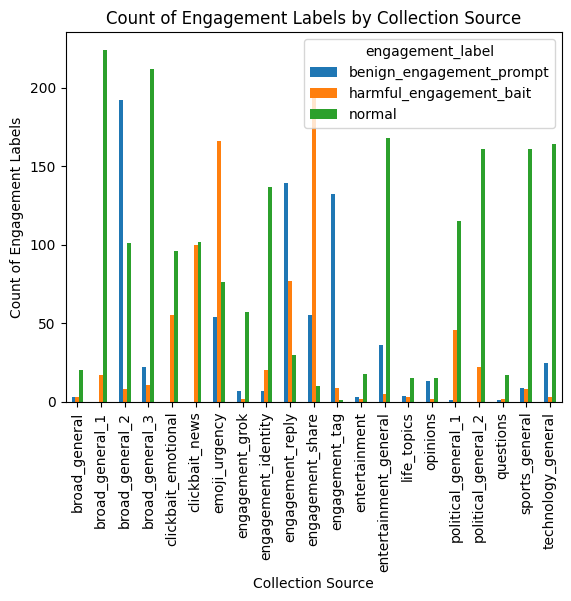

In [35]:
# Exploratory Plots

print(model_df.columns)
# Plotting engagement label distribution by collection source
count_bait_by_collection = model_df.groupby(['collection_source'])['engagement_label'].value_counts().unstack(fill_value=0)
count_bait_by_collection.plot(kind='bar', title='Count of Engagement Labels by Collection Source')
plt.xlabel('Collection Source')
plt.ylabel('Count of Engagement Labels')
plt.show()

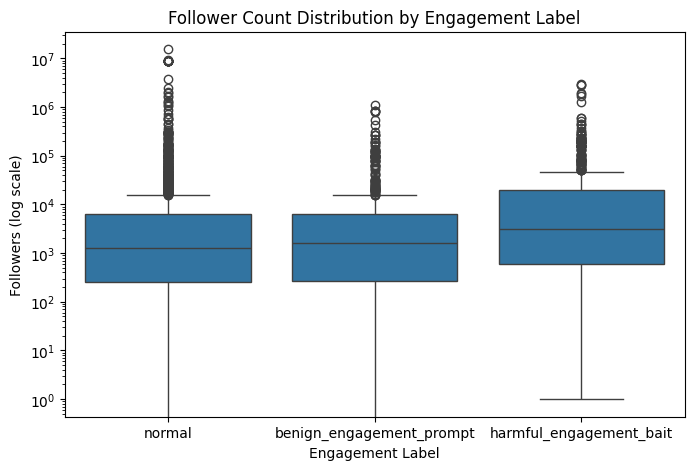

In [38]:
# Boxplot of followers count by engagement label
plt.figure(figsize=(8,5))
sns.boxplot(
    data=model_df,
    x='engagement_label',
    y='followers_count'
)
plt.title("Follower Count Distribution by Engagement Label")
plt.xlabel("Engagement Label")
plt.yscale('log') 
plt.ylabel("Followers (log scale)")
plt.show()

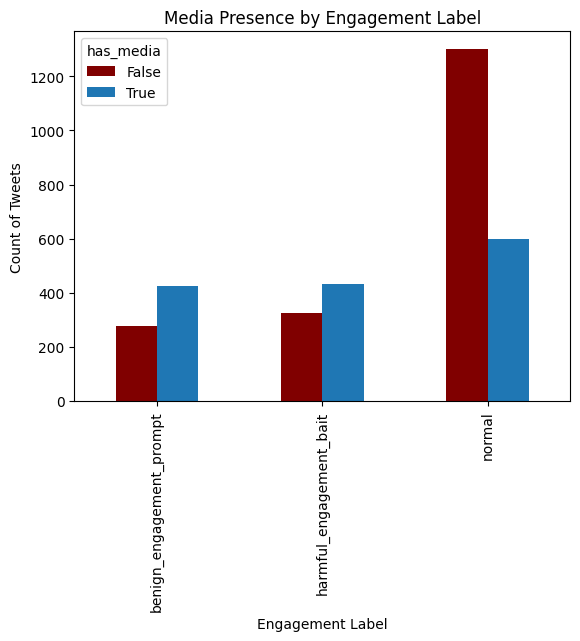

In [46]:
# Media frequency in each type of tweet
media_by_label = model_df.groupby('engagement_label')['has_media'].value_counts().unstack(fill_value=0)
media_by_label.plot(kind='bar', stacked=False, title='Media Presence by Engagement Label',color= ['maroon', '#1f77b4'],xlabel='Engagement Label', ylabel='Count of Tweets')
plt.show()

In [74]:
# Identifying common words in each bait type (excluding stopwords)
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

eda_df = model_df.copy()

eda_df["eda_text"] = (
    eda_df["clean_text"]
    .fillna("")
)

# Remove URLs
eda_df["eda_text"] = eda_df["eda_text"].str.replace(r"http\S+", "", regex=True)

# Remove punctuation but KEEP capitalization
eda_df["eda_text"] = eda_df["eda_text"].str.replace(r"[^A-Za-z\s]", " ", regex=True)

# Collapse whitespace
eda_df["eda_text"] = eda_df["eda_text"].str.replace(r"\s+", " ", regex=True)


eda_df["tokens"] = eda_df["eda_text"].apply(
    lambda text: [
        word
        for word in text.split()
        if word.lower() not in stop_words
        and len(word) > 2
    ]
)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rj2wo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [75]:
def most_common_words(df, label, n=30):

    words = []

    subset = df[df["engagement_label"] == label]

    for tokens in subset["tokens"]:
        words.extend(tokens)

    return Counter(words).most_common(n)

normal_words = most_common_words(
    eda_df,
    "normal"
)

benign_words = most_common_words(
    eda_df,
    "benign_engagement_prompt"
)

harmful_words = most_common_words(
    eda_df,
    "harmful_engagement_bait"
)

normal_df = pd.DataFrame(
    normal_words,
    columns=["word","count"]
)

benign_df = pd.DataFrame(
    benign_words,
    columns=["word","count"]
)

harmful_df = pd.DataFrame(
    harmful_words,
    columns=["word","count"]
)

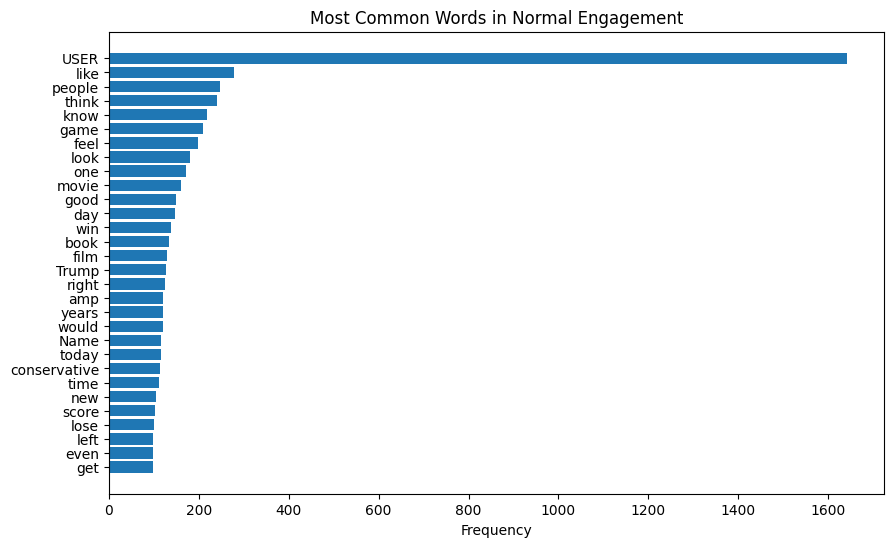

In [76]:
# Normal Plot
plt.figure(figsize=(10,6))

plt.barh(
    normal_df["word"],
    normal_df["count"]
)

plt.gca().invert_yaxis()

plt.title("Most Common Words in Normal Engagement")

plt.xlabel("Frequency")

plt.show()

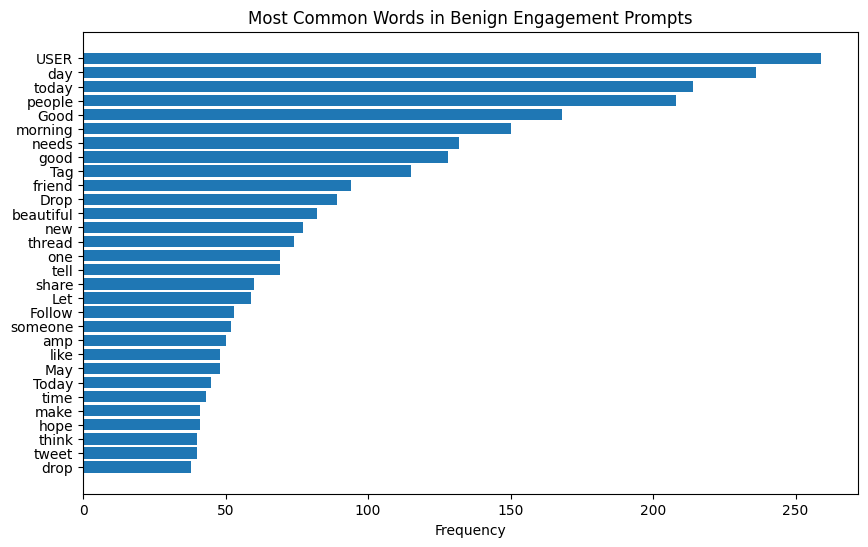

In [77]:
# Benign Plot
plt.figure(figsize=(10,6))

plt.barh(
    benign_df["word"],
    benign_df["count"]
)

plt.gca().invert_yaxis()

plt.title("Most Common Words in Benign Engagement Prompts")

plt.xlabel("Frequency")

plt.show()

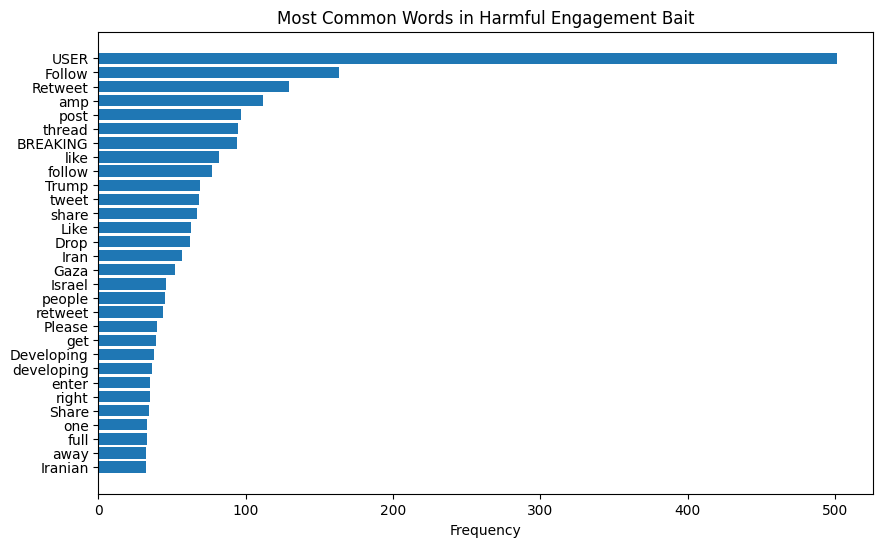

In [78]:

# Harmful Plot
plt.figure(figsize=(10,6))

plt.barh(
    harmful_df["word"],
    harmful_df["count"]
)

plt.gca().invert_yaxis()

plt.title("Most Common Words in Harmful Engagement Bait")

plt.xlabel("Frequency")

plt.show()

# Step 5.5: Exploratory PCA to address multicollinearity and redundant predictors

In [85]:
# Exploratory PCA to determine redundant predictors

numeric_cols = [
    "text_length",
    "uppercase_ratio",
    "exclamation_count",
    "question_count",

    "like_count",
    "reply_count",
    "retweet_count",
    "quote_count",
    "engagement_total",
    "reply_like_ratio",
    "quote_like_ratio",

    "followers_count",
    "following_count",
    "user_tweet_count",
    "listed_count",
    "user_like_count",
    "user_media_count",
    "follower_following_ratio",

    "tweet_reported_media_count",
    "media_count_from_media_table",

    "num_photos",
    "num_videos",
    "num_gifs",

    "max_media_width",
    "max_media_height",
    "max_duration_ms",

    "avg_media_width",
    "avg_media_height"
]

X = model_df[numeric_cols].copy()

X = X.fillna(0)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

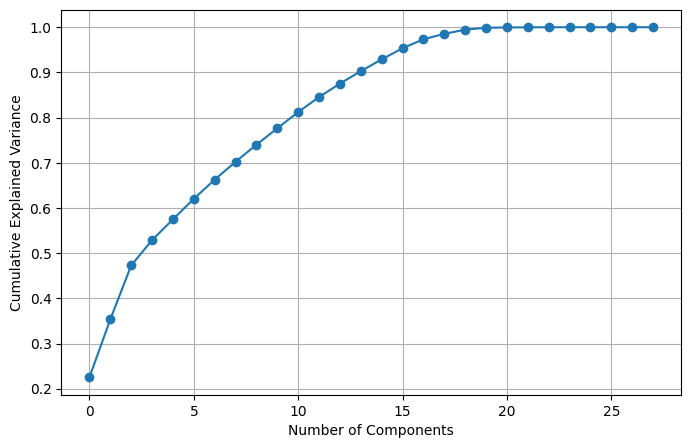

In [90]:

explained = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))

plt.plot(
    np.cumsum(explained),
    marker="o"
)

plt.xlabel("Number of Components")

plt.ylabel("Cumulative Explained Variance")

plt.grid(True)

plt.show()

In [91]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[
        f"PC{i+1}"
        for i in range(len(X.columns))
    ]
)

display(loadings.round(3))

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28
text_length,0.098,0.017,0.052,-0.043,-0.097,-0.046,-0.466,0.241,-0.239,0.223,...,0.028,0.016,-0.008,-0.002,0.001,0.000,-0.000,-0.000,0.000,-0.000
uppercase_ratio,0.112,-0.021,0.019,0.105,0.420,0.142,0.081,0.002,0.304,0.289,...,0.044,-0.003,-0.011,-0.000,-0.001,-0.001,0.000,0.000,0.000,0.000
exclamation_count,0.049,-0.034,-0.004,-0.016,0.453,0.467,0.065,-0.304,-0.009,0.255,...,-0.025,-0.004,0.000,0.007,-0.000,0.001,-0.000,-0.000,0.000,0.000
question_count,0.003,-0.005,-0.019,0.012,-0.291,0.334,-0.242,-0.177,-0.505,0.483,...,-0.012,-0.006,0.001,0.001,0.000,0.003,-0.000,-0.000,-0.000,-0.000
like_count,0.104,0.441,-0.219,-0.037,0.054,-0.083,-0.022,-0.013,-0.039,0.003,...,-0.056,0.003,0.006,0.000,-0.000,-0.000,0.077,-0.062,-0.068,-0.628
reply_count,0.089,0.376,-0.188,-0.087,-0.072,0.132,0.014,-0.054,-0.022,-0.170,...,0.085,-0.004,-0.002,0.001,-0.000,-0.000,0.008,-0.006,-0.007,-0.064
retweet_count,0.103,0.360,-0.169,0.001,0.071,-0.026,0.063,-0.017,-0.013,0.096,...,0.039,-0.006,-0.012,0.001,-0.000,-0.000,0.013,-0.010,-0.011,-0.105
quote_count,0.056,0.289,-0.137,0.006,-0.049,0.021,-0.128,-0.097,0.162,0.040,...,0.007,-0.015,-0.001,-0.000,-0.000,0.000,0.001,-0.001,-0.001,-0.007
engagement_total,0.111,0.458,-0.226,-0.038,0.049,-0.062,-0.010,-0.019,-0.035,0.002,...,-0.034,0.002,0.003,0.000,-0.000,-0.000,-0.091,0.073,0.081,0.745
reply_like_ratio,-0.055,0.014,-0.011,-0.198,-0.337,0.517,-0.016,0.056,0.038,-0.464,...,-0.014,0.005,0.004,-0.001,-0.001,0.000,0.000,-0.000,-0.000,-0.000


In [93]:
pc1 = (
    loadings["PC1"]
    .abs()
    .sort_values(ascending=False)
)

display(pc1)

pc2 = (
    loadings["PC2"]
    .abs()
    .sort_values(ascending=False)
)

display(pc2)

pc3 = (
    loadings["PC3"]
    .abs()
    .sort_values(ascending=False)
)

display(pc3)

max_media_height                3.749623e-01
max_media_width                 3.723011e-01
avg_media_height                3.673002e-01
avg_media_width                 3.640686e-01
media_count_from_media_table    3.598031e-01
tweet_reported_media_count      3.566303e-01
num_photos                      3.162297e-01
num_videos                      1.324594e-01
uppercase_ratio                 1.119727e-01
engagement_total                1.105964e-01
like_count                      1.041026e-01
retweet_count                   1.034705e-01
text_length                     9.772092e-02
reply_count                     8.924103e-02
quote_count                     5.633563e-02
reply_like_ratio                5.506004e-02
max_duration_ms                 5.121662e-02
exclamation_count               4.891612e-02
user_tweet_count                3.588704e-02
follower_following_ratio        3.518956e-02
followers_count                 2.730575e-02
quote_like_ratio                1.735787e-02
following_

engagement_total                4.579017e-01
like_count                      4.410989e-01
reply_count                     3.759280e-01
retweet_count                   3.601701e-01
quote_count                     2.886454e-01
followers_count                 2.483559e-01
user_tweet_count                2.198148e-01
follower_following_ratio        2.195728e-01
listed_count                    2.032586e-01
num_photos                      7.964483e-02
following_count                 7.445345e-02
max_media_height                6.999777e-02
avg_media_height                6.765942e-02
media_count_from_media_table    6.730918e-02
tweet_reported_media_count      6.499954e-02
max_media_width                 5.542323e-02
avg_media_width                 5.204429e-02
max_duration_ms                 4.386913e-02
num_videos                      3.716924e-02
exclamation_count               3.378301e-02
num_gifs                        2.370507e-02
uppercase_ratio                 2.123513e-02
text_lengt

follower_following_ratio        4.825474e-01
user_tweet_count                4.816156e-01
followers_count                 4.755149e-01
listed_count                    3.212867e-01
engagement_total                2.261591e-01
like_count                      2.191100e-01
reply_count                     1.883337e-01
retweet_count                   1.691828e-01
quote_count                     1.366363e-01
max_media_height                5.695124e-02
avg_media_height                5.530917e-02
max_media_width                 5.428454e-02
num_photos                      5.225632e-02
avg_media_width                 5.214508e-02
text_length                     5.188719e-02
media_count_from_media_table    5.067305e-02
tweet_reported_media_count      4.890639e-02
quote_like_ratio                2.483211e-02
question_count                  1.891982e-02
uppercase_ratio                 1.888189e-02
reply_like_ratio                1.069424e-02
max_duration_ms                 9.270341e-03
following_

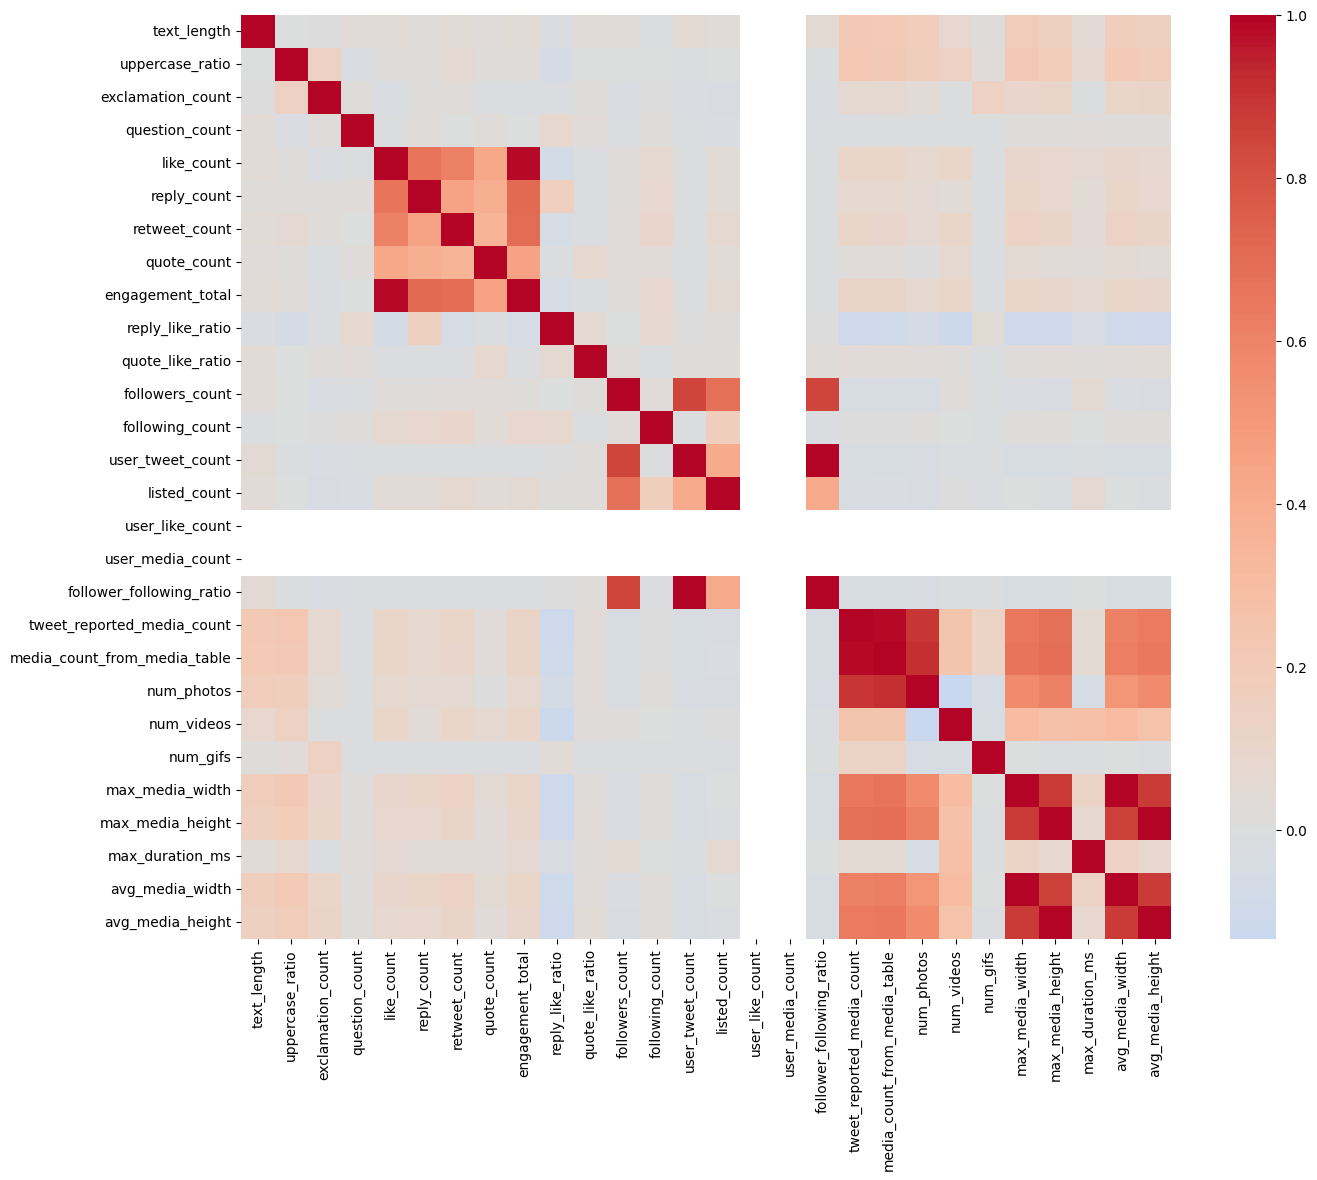

In [ ]:
plt.figure(figsize=(15,12))

sns.heatmap(
    X.corr(),
    cmap="coolwarm",
    center=0
)

plt.show()

# Step 6: Model Training and Evaluation

In [ ]:
# Redundant variables excluded form model training
X = [[
    'text','text_length','uppercase_ratio','exlamation_count','question_count',
    'has_url','has_mention','has_hashtag','verified','followers_count','following_count','user_tweet_count','user_media_count',
    'media_count_from_media_table','num_photos','num_videos','num_gifs','max_duration_ms','avg_media_width','avg_media_height'
]]
Y=['engagement_label']

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)



Index(['tweet_id', 'author_id', 'text', 'clean_text', 'created_at', 'lang',
       'text_length', 'uppercase_ratio', 'exclamation_count', 'question_count',
       'has_url', 'has_mention', 'has_hashtag', 'like_count', 'reply_count',
       'retweet_count', 'quote_count', 'engagement_total', 'reply_like_ratio',
       'quote_like_ratio', 'collection_source', 'search_query', 'username',
       'display_name', 'verified', 'followers_count', 'following_count',
       'user_tweet_count', 'listed_count', 'user_like_count',
       'user_media_count', 'follower_following_ratio', 'has_media',
       'tweet_reported_media_count', 'media_count_from_media_table',
       'num_photos', 'num_videos', 'num_gifs', 'has_photo', 'has_video',
       'has_gif', 'num_alt_text', 'has_alt_text', 'max_media_width',
       'max_media_height', 'max_duration_ms', 'avg_media_width',
       'avg_media_height', 'media_types', 'engagement_label',
       'is_engagement_bait', 'is_harmful_bait', 'bait_type',
       'la